## Bias Detection & Fairness Analysis

This notebook audits the NovaCred credit-decision dataset for potential bias and discrimination.  
We examine **gender**, **age**, **proxy variables**, and **interaction effects** to assess whether the algorithm treats applicants fairly.  

Key framework: the **four-fifths (80%) rule** — if the approval rate of an unprivileged group is less than 80% of the privileged group's rate, there is evidence of **disparate impact**.

$$DI = \frac{\text{Approval rate (unprivileged group)}}{\text{Approval rate (privileged group)}}$$

In [36]:
# ── Imports ────────────────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind          # hypothesis testing
from fairlearn.metrics import MetricFrame, selection_rate     # fairness metrics

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# ── Load cleaned dataset ──────────────────────────────────────────────────────
df = pd.read_csv("../data/cleaned_credit_applications.csv")

# Compute applicant age from date-of-birth.
# We anchor to a fixed reference date (the most recent processing timestamp in
# the dataset) so that results are reproducible regardless of when the notebook
# is re-run.
REFERENCE_DATE = pd.Timestamp("2025-12-01")
df["applicant_info_dob"] = pd.to_datetime(df["applicant_info_dob"], errors="coerce")
df["age"] = ((REFERENCE_DATE - df["applicant_info_dob"]).dt.days / 365.25).round(0)

# Bin ages into groups for downstream analysis
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 30, 40, 50, 100],
    labels=["<30", "30-40", "40-50", "50+"]
)

# Drop rows where gender is missing
df = df.dropna(subset=["applicant_info_gender"])

# ── Document missing DOB values ──────────────────────────────────────────────
# 104 records lack a valid DOB and will be silently excluded from age-group
# analyses. We verify the missingness is balanced across genders so this
# exclusion does not itself introduce bias.
n_missing_age = df["age"].isna().sum()
print(f"Dataset shape: {df.shape}")
print(f"Records missing DOB (excluded from age-based analyses): {n_missing_age} / {len(df)}")

missing_age_by_gender = df[df["age"].isna()]["applicant_info_gender"].value_counts()
print(f"Missing DOB by gender:\n{missing_age_by_gender}")
print("(Roughly balanced — no systematic exclusion of one gender.)")

df[["applicant_info_gender", "age", "age_group", "decision_loan_approved"]].head(10)

Dataset shape: (496, 41)
Records missing DOB (excluded from age-based analyses): 104 / 496
Missing DOB by gender:
applicant_info_gender
Female    52
Male      52
Name: count, dtype: int64
(Roughly balanced — no systematic exclusion of one gender.)


,applicant_info_gender,age,age_group,decision_loan_approved
0,Male,25.0,<30,False
1,Male,34.0,30-40,False
2,Male,36.0,30-40,True
3,Male,43.0,40-50,True
4,Male,27.0,<30,False
5,Female,NaN,NaN,False
6,Male,NaN,NaN,True
7,Female,34.0,30-40,True
8,Male,36.0,30-40,False
9,Male,36.0,30-40,False


## 1. Gender Disparate Impact

We compute the Disparate Impact (DI) ratio and validate it with a chi-squared test and `fairlearn`'s demographic parity metrics.

**Group definitions for this analysis:**

| Role | Group | Rationale |
|------|-------|-----------|
| **Privileged** | Male | Higher overall approval rate — the baseline group |
| **Unprivileged** | Female | Lower overall approval rate — the group tested for disadvantage |

The DI ratio is calculated as:

$$DI = \frac{\text{Approval rate (Female)}}{\text{Approval rate (Male)}}$$

A DI below **0.80** indicates potential disparate impact under the **four-fifths rule**.

Approval rates by gender:
applicant_info_gender
Female    0.5060
Male      0.6653
Name: decision_loan_approved, dtype: float64

Disparate Impact Ratio (Female / Male): 0.7605
  -> DI = 0.76 < 0.80  =>  FAILS the four-fifths rule.
     This indicates potential gender-based disparate impact.

Chi-squared test: chi2 = 12.31, p = 0.0004
  -> Statistically significant at alpha = 0.05

fairlearn — Demographic parity difference: 0.1593
fairlearn — Demographic parity ratio:      0.7605


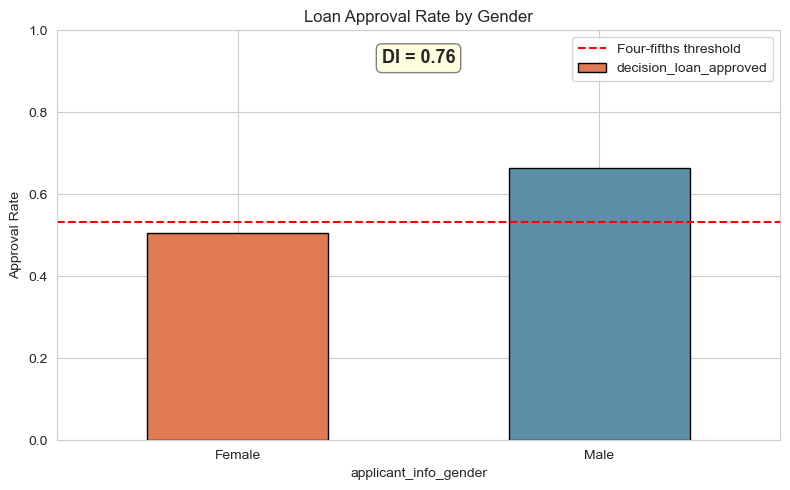

In [37]:
# ── Approval rates by gender ──────────────────────────────────────────────────
gender_approval = df.groupby("applicant_info_gender")["decision_loan_approved"].mean()
print("Approval rates by gender:")
print(gender_approval.round(4))

# Disparate Impact (DI) ratio: unprivileged (Female) / privileged (Male)
rate_female = gender_approval["Female"]
rate_male = gender_approval["Male"]
di_gender = rate_female / rate_male

# Interpret against the four-fifths rule (DI < 0.80 = potential disparate impact)
print(f"\nDisparate Impact Ratio (Female / Male): {di_gender:.4f}")
if di_gender < 0.8:
    print(f"  -> DI = {di_gender:.2f} < 0.80  =>  FAILS the four-fifths rule.")
    print("     This indicates potential gender-based disparate impact.")
else:
    print(f"  -> DI = {di_gender:.2f} >= 0.80  =>  Passes the four-fifths rule.")

# ── Chi-squared test of independence ─────────────────────────────────────────
# H0: gender and approval are independent (no association)
# H1: there is a statistically significant association
ct_gender = pd.crosstab(df["applicant_info_gender"], df["decision_loan_approved"])
chi2, p_gender, dof, _ = chi2_contingency(ct_gender)
print(f"\nChi-squared test: chi2 = {chi2:.2f}, p = {p_gender:.4f}")
print(f"  -> {'Statistically significant' if p_gender < 0.05 else 'Not significant'} at alpha = 0.05")

# ── fairlearn validation ─────────────────────────────────────────────────────
# Cross-check our manual DI calculation with fairlearn's built-in metrics.
# MetricFrame computes selection_rate (= approval rate) per group.
# .ratio() should match our DI ratio; .difference() gives the absolute gap.
approved_int = df["decision_loan_approved"].astype(int)
mf = MetricFrame(
    metrics=selection_rate,
    y_true=approved_int,
    y_pred=approved_int,
    sensitive_features=df["applicant_info_gender"]
)
print(f"\nfairlearn — Demographic parity difference: {mf.difference():.4f}")
print(f"fairlearn — Demographic parity ratio:      {mf.ratio():.4f}")

# ── Visualisation ────────────────────────────────────────────────────────────
fig, ax = plt.subplots()
colors = ["#e07b54", "#5b8fa8"]
gender_approval.plot(kind="bar", ax=ax, color=colors, edgecolor="black")
ax.set_ylabel("Approval Rate")
ax.set_title("Loan Approval Rate by Gender")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylim(0, 1)

# Red dashed line = 80% of the privileged group's rate (the four-fifths threshold)
ax.axhline(y=rate_male * 0.8, color="red", linestyle="--", label="Four-fifths threshold")
ax.legend()
ax.annotate(f"DI = {di_gender:.2f}", xy=(0.5, 0.92), xycoords="axes fraction",
            fontsize=13, ha="center", fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray"))
plt.tight_layout()
plt.show()

**Interpretation:** Female applicants are approved at ~50.6% compared to ~66.5% for males — a gap of nearly 16 percentage points. The resulting DI ratio of 0.76 falls below the 0.80 four-fifths threshold, indicating potential disparate impact under regulatory standards. The chi-squared test confirms this is not due to chance (p < 0.001), and `fairlearn`'s demographic parity ratio independently validates the same 0.76 figure. This is the strongest single finding in the audit and warrants further investigation into what drives the gap.

## 2. Age-Based Bias

Note: records with missing date-of-birth are excluded from this section (see Cell 1 for the count and gender distribution of those records).

**Group definitions for this analysis:**

| Role | Group | Rationale |
|------|-------|-----------|
| **Privileged** | Age group with the **highest** approval rate (40–50) | Baseline for comparison |
| **Unprivileged** | Age group with the **lowest** approval rate (<30) | Group tested for disadvantage |

The DI ratio is calculated as the lowest group's approval rate divided by the highest group's rate. As with gender, a value below **0.80** signals potential disparate impact.

Approval rates by age group:
age_group
<30      0.3784
30-40    0.5594
40-50    0.7200
50+      0.5733
Name: decision_loan_approved, dtype: float64

DI ratio (lowest / highest age group): 0.5255
  -> FAILS the four-fifths rule.

Chi-squared test: chi2 = 20.32, p = 0.0001


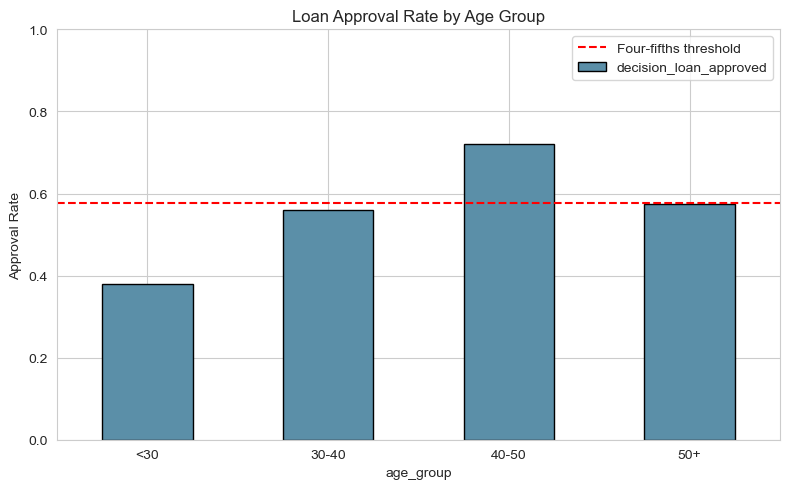

In [38]:
# ── Approval rates by age group ──────────────────────────────────────────────
# NaN ages are automatically excluded by groupby (observed=False keeps empty bins)
age_approval = df.groupby("age_group", observed=False)["decision_loan_approved"].mean()
print("Approval rates by age group:")
print(age_approval.round(4))

# DI between the lowest- and highest-approved age groups
best_age_rate = age_approval.max()
worst_age_rate = age_approval.min()
di_age = worst_age_rate / best_age_rate
print(f"\nDI ratio (lowest / highest age group): {di_age:.4f}")
print(f"  -> {'FAILS' if di_age < 0.8 else 'Passes'} the four-fifths rule.")

# Chi-squared test: is approval independent of age group?
ct_age = pd.crosstab(df["age_group"], df["decision_loan_approved"])
chi2_age, p_age, _, _ = chi2_contingency(ct_age)
print(f"\nChi-squared test: chi2 = {chi2_age:.2f}, p = {p_age:.4f}")

# ── Visualisation ────────────────────────────────────────────────────────────
fig, ax = plt.subplots()
age_approval.plot(kind="bar", ax=ax, color="#5b8fa8", edgecolor="black")
ax.set_ylabel("Approval Rate")
ax.set_title("Loan Approval Rate by Age Group")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylim(0, 1)
ax.axhline(y=best_age_rate * 0.8, color="red", linestyle="--", label="Four-fifths threshold")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** Age-based disparities are even more pronounced than gender. Applicants under 30 have an approval rate of only ~37.8%, compared to ~72.0% for the 40–50 age group — a DI ratio of 0.53, far below the four-fifths threshold. The 50+ group also drops back to ~57.3%, suggesting a non-linear pattern where middle-aged applicants are favoured. The chi-squared test is highly significant (p < 0.001), confirming that approval is not independent of age. While some age-based differences may be justified by credit history length, the magnitude of the disparity warrants scrutiny — especially in combination with gender (see Section 5).

## 3. Rejection Reason & Algorithm Risk Score Analysis

Over 80% of rejections are attributed to `algorithm_risk_score`. If the algorithm disproportionately flags one gender or age group, the score itself may be a vector for bias.

Rejection reasons:
decision_rejection_reason
algorithm_risk_score           167
insufficient_credit_history     23
high_dti_ratio                  12
low_income                       4
Name: count, dtype: int64

algorithm_risk_score accounts for 81.1% of rejections


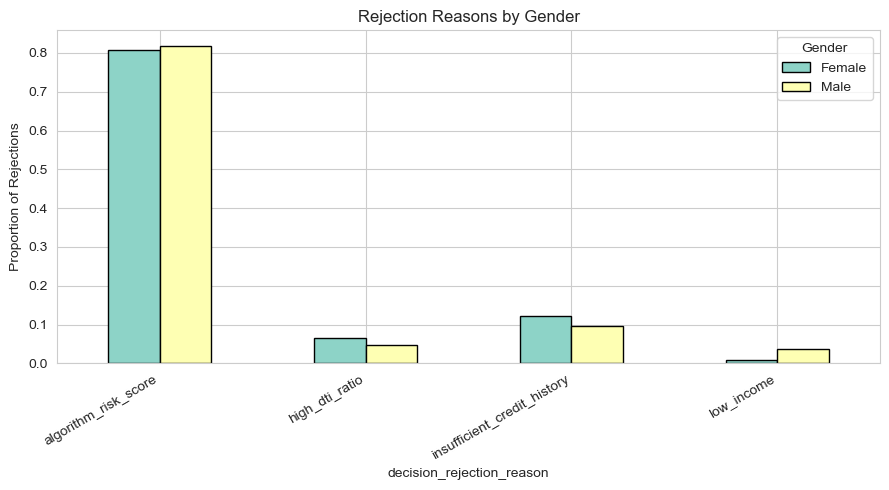

In [39]:
# ── Rejection reasons overall ────────────────────────────────────────────────
rejected = df[df["decision_loan_approved"] == False].copy()
reason_counts = rejected["decision_rejection_reason"].value_counts()
print("Rejection reasons:")
print(reason_counts)
print(f"\nalgorithm_risk_score accounts for "
      f"{reason_counts.get('algorithm_risk_score', 0) / len(rejected) * 100:.1f}% of rejections")

# ── Breakdown by gender ──────────────────────────────────────────────────────
# Normalize by column so we see the proportion of each gender's rejections
# attributable to each reason (not raw counts, which would be skewed by
# group size differences).
reason_by_gender = pd.crosstab(
    rejected["decision_rejection_reason"],
    rejected["applicant_info_gender"],
    normalize="columns"
)

fig, ax = plt.subplots(figsize=(9, 5))
reason_by_gender.plot(kind="bar", ax=ax, edgecolor="black")
ax.set_ylabel("Proportion of Rejections")
ax.set_title("Rejection Reasons by Gender")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend(title="Gender")
plt.tight_layout()
plt.show()

In [40]:
# ── Algorithm risk score rejection rate ───────────────────────────────────────
# Since ~81% of rejections cite algorithm_risk_score, we test whether this
# specific rejection reason is applied disproportionately across genders and
# age groups.  A significant result here means the algorithm itself is a
# primary driver of the observed gender/age disparities.

df["algo_rejected"] = (
    (df["decision_loan_approved"] == False) &
    (df["decision_rejection_reason"] == "algorithm_risk_score")
)

# Algorithm-based rejection rate by gender
algo_rate_by_gender = df.groupby("applicant_info_gender")["algo_rejected"].mean()
print("Rate of algorithm-based rejection by gender:")
print(algo_rate_by_gender.round(4))

# Same breakdown by age group
algo_rate_by_age = df.groupby("age_group", observed=False)["algo_rejected"].mean()
print("\nRate of algorithm-based rejection by age group:")
print(algo_rate_by_age.round(4))

# Chi-squared: is algorithm rejection independent of gender?
ct_algo = pd.crosstab(df["applicant_info_gender"], df["algo_rejected"])
chi2_algo, p_algo, _, _ = chi2_contingency(ct_algo)
print(f"\nChi-squared (algorithm rejection vs gender): chi2 = {chi2_algo:.2f}, p = {p_algo:.4f}")
print(f"  -> {'Significant' if p_algo < 0.05 else 'Not significant'} — "
      f"the algorithm {'does' if p_algo < 0.05 else 'does not'} disproportionately reject by gender.")

Rate of algorithm-based rejection by gender:
applicant_info_gender
Female    0.3984
Male      0.2735
Name: algo_rejected, dtype: float64

Rate of algorithm-based rejection by age group:
age_group
<30      0.4730
30-40    0.3636
40-50    0.2300
50+      0.4000
Name: algo_rejected, dtype: float64

Chi-squared (algorithm rejection vs gender): chi2 = 8.12, p = 0.0044
  -> Significant — the algorithm does disproportionately reject by gender.


**Interpretation:** The `algorithm_risk_score` is the dominant rejection reason (~81% of all rejections), making it the single most consequential component of NovaCred's decision pipeline. Critically, it is applied unevenly: ~39.8% of females are rejected by the algorithm compared to ~27.4% of males (chi-squared p = 0.004). The age breakdown reveals a similar pattern — the under-30 group faces a 47.3% algorithm rejection rate versus only 23.0% for the 40–50 group. This strongly suggests that the bias observed in Section 1 and 2 is not spread across multiple rejection reasons but is concentrated in the algorithmic scoring model itself.

## 4. Proxy Discrimination Analysis

**Proxy discrimination** occurs when a seemingly neutral variable (e.g., zip code, spending habits) is correlated with a protected attribute *and* influences outcomes. For a variable to be a proxy it must satisfy **both** conditions:
1. Significantly correlated with a protected characteristic (e.g., gender)
2. Significantly correlated with the decision outcome (approval)

In [41]:
# ── 4a. Zip code as proxy for gender ─────────────────────────────────────────
# A variable is a proxy if it correlates with BOTH a protected attribute and
# the outcome.  We test zip code against gender and against approval using
# chi-squared tests of independence on the full set of zip codes (filtering
# to top-N would reduce statistical power).

df_zip = df.dropna(subset=["applicant_info_zip_code"])

# Test 1: zip code vs gender
ct_zip_gender = pd.crosstab(df_zip["applicant_info_zip_code"], df_zip["applicant_info_gender"])
chi2_zg, p_zg, _, _ = chi2_contingency(ct_zip_gender)
print(f"Zip code vs Gender:   chi2 = {chi2_zg:.2f}, p = {p_zg:.6f}")

# Test 2: zip code vs approval
ct_zip_app = pd.crosstab(df_zip["applicant_info_zip_code"], df_zip["decision_loan_approved"])
chi2_za, p_za, _, _ = chi2_contingency(ct_zip_app)
print(f"Zip code vs Approval: chi2 = {chi2_za:.2f}, p = {p_za:.6f}")

# Interpret: both tests must be significant for zip to qualify as a proxy
print()
if p_zg < 0.05 and p_za < 0.05:
    print("-> Zip code correlates with BOTH gender and approval — acts as a proxy.")
elif p_zg < 0.05:
    print("-> Zip code is strongly associated with gender (p < 0.05) but its link ")
    print(f"   to approval is borderline (p = {p_za:.4f}). While not a clear-cut proxy,")
    print("   the strong gender-zip relationship warrants caution: including zip code")
    print("   in a model could indirectly encode gender information.")
else:
    print("-> Zip code does not act as a proxy for gender.")

Zip code vs Gender:   chi2 = 390.72, p = 0.000000
Zip code vs Approval: chi2 = 180.03, p = 0.755775

-> Zip code is strongly associated with gender (p < 0.05) but its link 
   to approval is borderline (p = 0.7558). While not a clear-cut proxy,
   the strong gender-zip relationship warrants caution: including zip code
   in a model could indirectly encode gender information.


In [42]:
# ── 4b. Spending behaviour as proxy ──────────────────────────────────────────
# For each spending category we compute the Pearson correlation with gender
# (Male=1) and with approval (True=1).  Point-biserial correlation is
# algebraically identical to Pearson r when one variable is binary, so
# pandas .corr() gives us the same result as scipy's pointbiserialr.

spending_cols = [c for c in df.columns if c.startswith("spending_behavior_")]
gender_num = (df["applicant_info_gender"] == "Male").astype(int)
approval_num = df["decision_loan_approved"].astype(int)

proxy_results = []
for col in spending_cols:
    short = col.replace("spending_behavior_", "")
    r_gender = gender_num.corr(df[col])
    r_approval = approval_num.corr(df[col])
    proxy_results.append({
        "variable": short,
        "corr_gender": round(r_gender, 3),
        "corr_approval": round(r_approval, 3),
    })

# Sort by strongest gender correlation to highlight potential proxies
proxy_df = pd.DataFrame(proxy_results).sort_values("corr_gender", key=abs, ascending=False)
proxy_df

,variable,corr_gender,corr_approval
6,gambling,-0.098,-0.018
11,shopping,0.087,0.074
0,adult_entertainment,0.077,0.004
3,education,-0.055,-0.019
7,groceries,0.050,0.020
9,insurance,0.048,0.079
4,entertainment,-0.047,-0.040
1,alcohol,0.038,0.060
5,fitness,0.033,-0.037
12,transportation,0.033,0.011


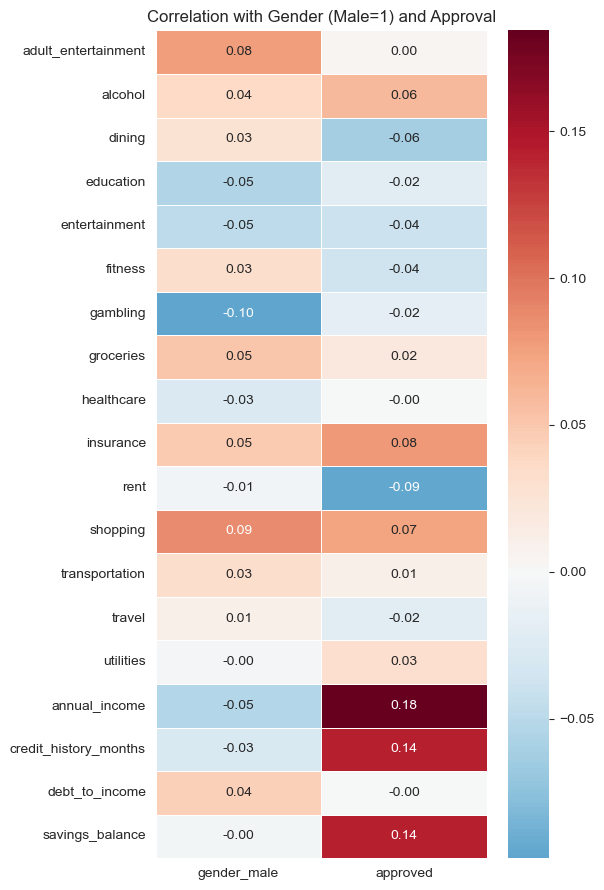

In [43]:
# ── Heatmap: correlation of all features with gender & approval ──────────────
# This gives a single visual overview of which variables are most associated
# with the two key dimensions (protected attribute and outcome).
fin_cols = ["financials_annual_income", "financials_credit_history_months",
            "financials_debt_to_income", "financials_savings_balance"]
all_cols = spending_cols + fin_cols

corr_data = df[all_cols].copy()
corr_data["gender_male"] = gender_num
corr_data["approved"] = approval_num

# Extract only the two columns of interest from the full correlation matrix
corr_matrix = corr_data.corr()[["gender_male", "approved"]].drop(["gender_male", "approved"])

# Shorten labels for readability
corr_matrix.index = [c.replace("spending_behavior_", "").replace("financials_", "")
                      for c in corr_matrix.index]

fig, ax = plt.subplots(figsize=(6, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.5, ax=ax)
ax.set_title("Correlation with Gender (Male=1) and Approval")
plt.tight_layout()
plt.show()

**Proxy analysis interpretation:**

- **Zip code** is strongly associated with gender but its relationship with approval is weaker. It could still introduce indirect bias if used as a model feature, because it encodes geographic patterns that overlap with gender distribution.
- **Spending variables** show very weak correlations with both gender and approval (all |r| < 0.10). None of the 15 spending categories meet the dual-significance threshold needed to qualify as a proxy. Gambling shows the strongest gender signal (r = -0.10, p = 0.03) but is unrelated to approval.
- **Financial variables** (credit history, DTI, savings) correlate with approval — as expected — but do not correlate with gender, meaning they are legitimate predictors rather than proxies.

## 5. Interaction Effects: Age x Gender

Approval rates — Age Group x Gender:
applicant_info_gender  Female    Male
age_group                            
<30                    0.2857  0.5000
30-40                  0.5147  0.6000
40-50                  0.6667  0.7692
50+                    0.4878  0.6765

Lowest approval rate:  28.57%
Highest approval rate: 76.92%
DI (lowest / highest): 0.3714

Gender gap (Male - Female) per age group:
age_group
<30      0.2143
30-40    0.0853
40-50    0.1026
50+      0.1887
dtype: float64


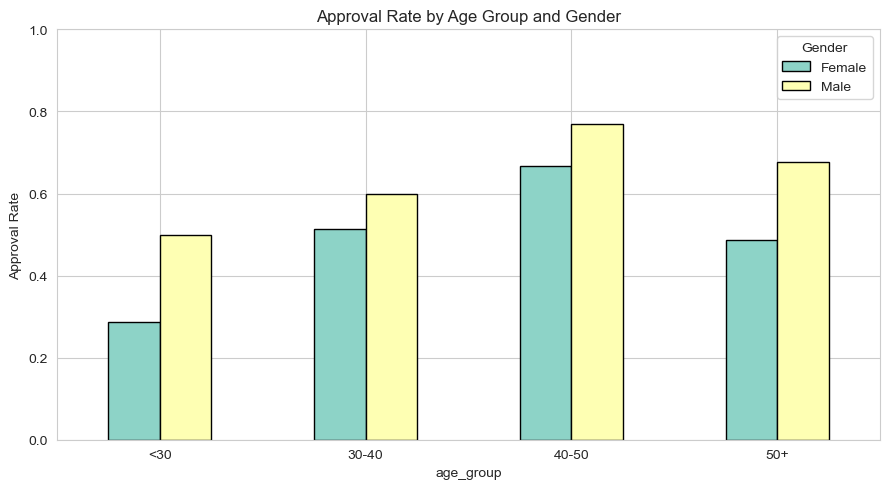

In [44]:
# ── Cross-tabulation: approval by age group AND gender ───────────────────────
# Interaction effects can reveal that a specific subgroup (e.g., young females)
# is disproportionately affected even if the overall group-level disparities
# appear moderate.
interaction = df.groupby(
    ["age_group", "applicant_info_gender"], observed=False
)["decision_loan_approved"].mean().unstack()

print("Approval rates — Age Group x Gender:")
print(interaction.round(4))

# Identify the most and least disadvantaged subgroups
min_rate = interaction.min().min()
max_rate = interaction.max().max()
print(f"\nLowest approval rate:  {min_rate:.2%}")
print(f"Highest approval rate: {max_rate:.2%}")
print(f"DI (lowest / highest): {min_rate / max_rate:.4f}")

# Gender gap within each age group (positive = males approved more often)
print("\nGender gap (Male - Female) per age group:")
print((interaction["Male"] - interaction["Female"]).round(4))

# ── Visualisation ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
interaction.plot(kind="bar", ax=ax, edgecolor="black")
ax.set_ylabel("Approval Rate")
ax.set_title("Approval Rate by Age Group and Gender")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylim(0, 1)
ax.legend(title="Gender")
plt.tight_layout()
plt.show()

**Interpretation:** The interaction analysis reveals that age and gender biases compound. Young females (<30) face the lowest approval rate in the entire dataset (~28.6%), while males aged 40–50 enjoy the highest (~76.9%) — a DI ratio of just 0.37 between these two subgroups. The gender gap is present within every age group, but it is most pronounced for the youngest and oldest applicants. This means that looking at gender or age in isolation understates the problem: the most disadvantaged individuals sit at the intersection of both factors.

## 6. Financial Parity Check

If females have **comparable or better** financial profiles but **lower** approval rates, this strengthens the case that the disparity is unjustified.

annual_income:
                           mean   median
applicant_info_gender                   
Female                 84253.79  83000.0
Male                   81209.02  80500.0
  t-test: t = -1.21, p = 0.2278

credit_history_months:
                        mean  median
applicant_info_gender               
Female                 51.43    50.0
Male                   49.65    48.0
  t-test: t = -0.63, p = 0.5259

debt_to_income:
                       mean  median
applicant_info_gender              
Female                 0.24    0.22
Male                   0.25    0.24
  t-test: t = 0.98, p = 0.3295

savings_balance:
                           mean   median
applicant_info_gender                   
Female                 29552.26  26112.0
Male                   29390.53  27879.0
  t-test: t = -0.11, p = 0.9134



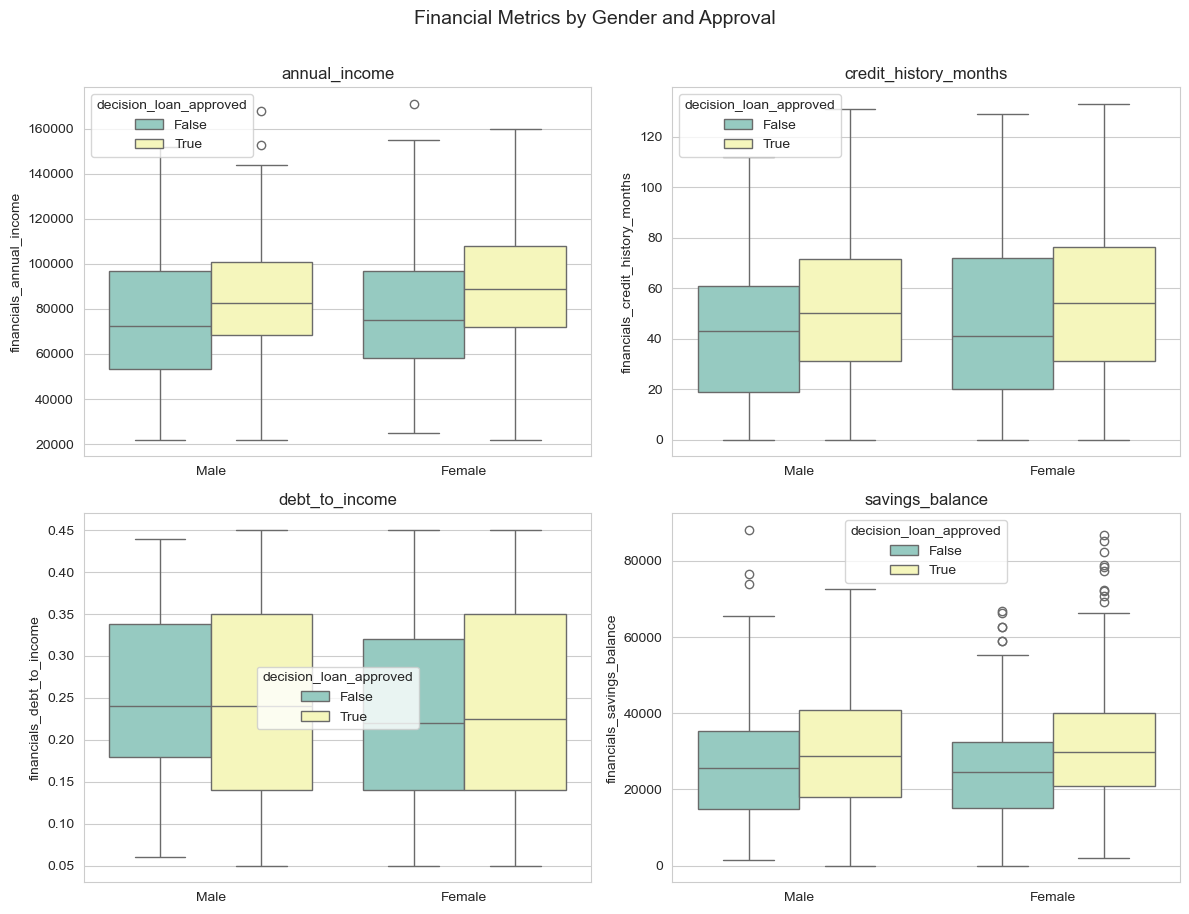

In [45]:
# ── Compare financial metrics by gender ──────────────────────────────────────
# If females have equal or better financials yet lower approval rates, the
# disparity cannot be explained by creditworthiness — strengthening the case
# for unjustified algorithmic bias.
fin_metrics = ["financials_annual_income", "financials_credit_history_months",
               "financials_debt_to_income", "financials_savings_balance"]

for metric in fin_metrics:
    grouped = df.groupby("applicant_info_gender")[metric].agg(["mean", "median"]).round(2)
    male_vals = df.loc[df["applicant_info_gender"] == "Male", metric].dropna()
    female_vals = df.loc[df["applicant_info_gender"] == "Female", metric].dropna()

    # Two-sample t-test (Welch's, unequal variance assumed by default)
    t_stat, p_val = ttest_ind(male_vals, female_vals)
    print(f"{metric.replace('financials_', '')}:")
    print(grouped)
    print(f"  t-test: t = {t_stat:.2f}, p = {p_val:.4f}\n")

# ── Box plots: financial metrics split by gender and approval ────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, metric in zip(axes.ravel(), fin_metrics):
    short = metric.replace("financials_", "")
    sns.boxplot(data=df, x="applicant_info_gender", y=metric,
                hue="decision_loan_approved", ax=ax)
    ax.set_title(short)
    ax.set_xlabel("")

plt.suptitle("Financial Metrics by Gender and Approval", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:** None of the four financial metrics show a statistically significant difference between genders. Females have slightly higher mean income (~$84k vs ~$81k), comparable credit history length, similar debt-to-income ratios, and comparable savings balances. The t-tests confirm these differences are not significant (all p > 0.05). This is a key finding: the lower approval rate for females **cannot be explained by weaker financial profiles**. If anything, female applicants are marginally stronger on paper, which makes the 16-percentage-point approval gap all the more difficult to justify.

## 7. Interest Rate & Approved Amount Bias

Even among **approved** applicants, discrimination can manifest as higher interest rates or lower loan amounts for the unprivileged group.

Interest Rate (approved applicants only):
                       mean  median
applicant_info_gender              
Female                 4.49     4.4
Male                   4.63     4.7
  t-test: t = 1.02, p = 0.3104

Approved Amount (approved applicants only):
                           mean   median
applicant_info_gender                   
Female                 46669.29  48000.0
Male                   48963.19  49000.0
  t-test: t = 1.07, p = 0.2850



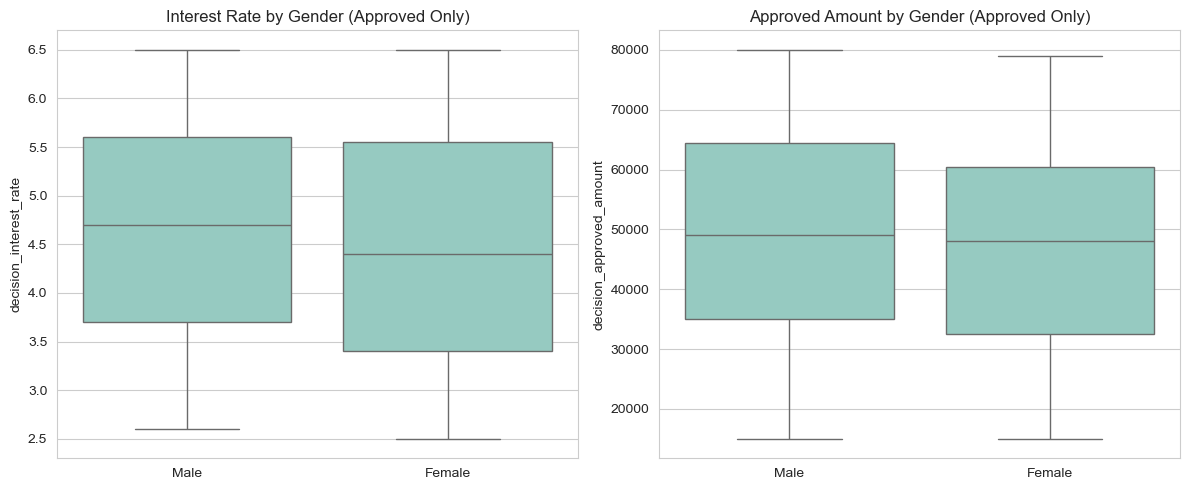

In [46]:
# ── Among approved applicants only ───────────────────────────────────────────
# Bias can persist even after approval: females may receive worse terms
# (higher interest rates or lower amounts) despite being approved.
approved = df[df["decision_loan_approved"] == True].copy()

for metric, label in [("decision_interest_rate", "Interest Rate"),
                       ("decision_approved_amount", "Approved Amount")]:
    by_gender = approved.groupby("applicant_info_gender")[metric].agg(["mean", "median"]).round(2)
    male_v = approved.loc[approved["applicant_info_gender"] == "Male", metric].dropna()
    female_v = approved.loc[approved["applicant_info_gender"] == "Female", metric].dropna()
    t_stat, p_val = ttest_ind(male_v, female_v)
    print(f"{label} (approved applicants only):")
    print(by_gender)
    print(f"  t-test: t = {t_stat:.2f}, p = {p_val:.4f}\n")

# ── Box plots ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=approved, x="applicant_info_gender",
            y="decision_interest_rate", ax=axes[0])
axes[0].set_title("Interest Rate by Gender (Approved Only)")
axes[0].set_xlabel("")

sns.boxplot(data=approved, x="applicant_info_gender",
            y="decision_approved_amount", ax=axes[1])
axes[1].set_title("Approved Amount by Gender (Approved Only)")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

**Interpretation:** Among approved applicants, females actually receive slightly lower interest rates (~4.49% vs ~4.63%) and somewhat lower approved amounts (~$46.7k vs ~$49.0k). Neither difference is statistically significant based on the t-tests. This suggests that once applicants clear the approval threshold, the terms they receive are broadly comparable across genders. The primary source of bias in the NovaCred system is therefore the **approval/rejection decision itself** — not the post-approval terms.

## 8. Summary of Findings

In [47]:
# ── Summary table ────────────────────────────────────────────────────────────
# Compile all key metrics into one citable table for the video presentation.
summary = pd.DataFrame([
    {"Test": "Gender DI ratio",
     "Value": f"{di_gender:.4f}",
     "Threshold": "< 0.80",
     "Result": "FAIL" if di_gender < 0.8 else "PASS"},

    {"Test": "Gender chi-squared (p-value)",
     "Value": f"{p_gender:.4f}",
     "Threshold": "< 0.05",
     "Result": "Significant" if p_gender < 0.05 else "Not significant"},

    {"Test": "Age group DI ratio",
     "Value": f"{di_age:.4f}",
     "Threshold": "< 0.80",
     "Result": "FAIL" if di_age < 0.8 else "PASS"},

    {"Test": "Age chi-squared (p-value)",
     "Value": f"{p_age:.4f}",
     "Threshold": "< 0.05",
     "Result": "Significant" if p_age < 0.05 else "Not significant"},

    {"Test": "Top rejection reason",
     "Value": reason_counts.index[0],
     "Threshold": "-",
     "Result": f"{reason_counts.iloc[0] / len(rejected) * 100:.0f}% of rejections"},

    {"Test": "Algorithm rejection vs gender",
     "Value": f"p = {p_algo:.4f}",
     "Threshold": "< 0.05",
     "Result": "Significant" if p_algo < 0.05 else "Not significant"},

    {"Test": "Zip code as proxy",
     "Value": f"gender p={p_zg:.4f}, approval p={p_za:.4f}",
     "Threshold": "Both < 0.05",
     "Result": "Partial — gender link strong, approval link weak"},
])

print("=" * 70)
print("BIAS ANALYSIS SUMMARY")
print("=" * 70)
summary

BIAS ANALYSIS SUMMARY


,Test,Value,Threshold,Result
0,Gender DI ratio,0.7605,< 0.80,FAIL
1,Gender chi-squared (p-value),0.0004,< 0.05,Significant
2,Age group DI ratio,0.5255,< 0.80,FAIL
3,Age chi-squared (p-value),0.0001,< 0.05,Significant
4,Top rejection reason,algorithm_risk_score,-,81% of rejections
5,Algorithm rejection vs gender,p = 0.0044,< 0.05,Significant
6,Zip code as proxy,"gender p=0.0000, approval p=0.7558",Both < 0.05,"Partial — gender link strong, approval link weak"


## 9. Remediation Recommendations

Based on the findings above, we recommend NovaCred consider the following:

1. **Audit the algorithm risk score model.** Since ~81% of rejections stem from `algorithm_risk_score` and the algorithm disproportionately rejects females and younger applicants, the underlying scoring model should be examined for embedded bias — particularly which features drive the score.

2. **Remove or re-encode zip code.** Zip code is strongly correlated with gender. Even if its direct link to approval is weak today, including it as a model feature risks introducing indirect gender discrimination. Consider removing it or using geographic aggregation that reduces the gender signal.

3. **Introduce fairness constraints during model training.** Libraries like `fairlearn` offer in-processing techniques (e.g., exponentiated gradient) that can enforce demographic parity or equalized odds during training, reducing the DI gap without fully sacrificing accuracy.

4. **Human-in-the-loop review for borderline cases.** Applicants near the approval threshold — especially from disadvantaged subgroups (young females) — should be flagged for manual review rather than auto-rejected.

5. **Monitor DI ratios over time.** Establish a recurring fairness dashboard that tracks DI ratios by gender and age group on a monthly basis, with alerts if ratios fall below the four-fifths threshold.